<a href="https://colab.research.google.com/github/pratbharat/-advancecfdwithpratyush/blob/main/2D_condcution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Simple Neural Network
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
'''
1. PINNS Algorithm
2. PDE Loss
3. Intial Loss
4. BC Loss
5. Generate the Data
6. Heat Soruce
7. Train model
8. Plot the results
9. Test the model

'''

'\n1. PINNS Algorithm\n2. PDE Loss \n3. Intial Loss\n4. BC Loss\n5. Generate the Data \n6. Heat Soruce \n7. Train model\n8. Plot the results\n9. Test the model\n\n\n'

In [44]:
#Create Neural Network Model = d2T/dx2 = 0
class PINN_Model(nn.Module):
    def __init__(self, layers, neurons, activation= nn.Tanh()):
        super(PINN_Model, self).__init__()
        self.activation = activation
        self.layers = nn.ModuleList()
        self.neurons = neurons
        self.layers.append(nn.Linear(3,neurons)) #3 input-> neurons
        for i in range(layers-1):
            self.layers.append(nn.Linear(neurons,neurons))
        self.layers.append(nn.Linear(neurons,1)) #1 output

   #RELU= <0 0> linear =>
   #Tanh = Continuous

    def forward(self,x,y,t):
        inputs = torch.cat([x,y,t],1)
        output= inputs
        for i in self.layers[:-1]:
            output = self.activation(i(output))
        output = self.layers[-1](output) + 25
        return output

In [11]:
x1 =  torch.arange(5)
print(x1)
x2 = torch.arange(6)
print(x2)
torch.cat([x1,x2],0)

tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4, 5])


tensor([0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 5])

In [45]:
model = PINN_Model (10,30)

In [46]:
model

PINN_Model(
  (activation): Tanh()
  (layers): ModuleList(
    (0): Linear(in_features=3, out_features=30, bias=True)
    (1-9): 9 x Linear(in_features=30, out_features=30, bias=True)
    (10): Linear(in_features=30, out_features=1, bias=True)
  )
)

In [14]:
#PDE_RESIDUAL
#Loss  = pde_loss + loss_BC + loss_IC
def pde_residual(model,x,y,t,eps, f):

  x = x.clone().detach().requires_grad_(True)
  y = y.clone().detach().requires_grad_(True)
  t = t.clone().detach().requires_grad_(True)

  T = model(x,y,t)

  #Compute the first order derivative
  T_x = torch.autograd.grad(T,x,grad_outputs=torch.ones_like(T),create_graph=True)[0]
  T_y = torch.autograd.grad(T,y,grad_outputs=torch.ones_like(T),create_graph=True)[0]
  T_t = torch.autograd.grad(T,t,grad_outputs=torch.ones_like(T),create_graph=True)[0]

  #Second order derivative
  T_xx = torch.autograd.grad(T_x,x,grad_outputs=torch.ones_like(T_x),create_graph=True)[0]
  T_yy = torch.autograd.grad(T_y,y,grad_outputs=torch.ones_like(T_y),create_graph=True)[0]

  #Residual
  residual = T_t - eps * (T_xx + T_yy) - f
  return torch.mean(residual**2)

In [15]:
def intial_loss(model, x, y, t, T0):
  T = model(x,y,t)
  return torch.mean((T-T0)**2)

In [16]:
def boundary_loss(model, x, y, t, length):
  T = model(x,y,t)
  x_boundary = (x<= 1e-6) | (x>= length -1e-6)
  y_boundary = (y<= 1e-6) | (y>= length -1e-6)
  T_x = torch.autograd.grad(T,x,grad_outputs=torch.ones_like(T),create_graph=True)[0]
  T_y = torch.autograd.grad(T,y,grad_outputs=torch.ones_like(T),create_graph=True)[0]
  loss_x = torch.mean(T_x[x_boundary]**2)
  loss_y = torch.mean(T_y[y_boundary]**2)
  return torch.mean(loss_x+ loss_y)

In [26]:
def generate_dats (n_points, length, total_time):
  x = torch.rand(n_points,1, requires_grad= True)*length
  y = torch.rand(n_points,1, requires_grad= True)*length
  t = torch.rand(n_points,1, requires_grad= True)*total_time

  n_boundary = n_points//10
  x_boundary = torch.cat([torch.zeros(n_boundary, 1), torch.full((n_boundary,1), length)], dim=0 )
  y_boundary = torch.cat([torch.zeros(n_boundary, 1), torch.full((n_boundary,1), length)], dim=0 )
  t_boudary = torch.rand(2*n_boundary,1,requires_grad= True )*total_time
  x = torch.cat([x, x_boundary, torch.rand(2*n_boundary, 1)* length ], dim=0)
  y = torch.cat([y, torch.rand(2*n_boundary, 1)* length, y_boundary ], dim=0)
  t = torch.cat([t, t_boudary, t_boudary], dim=0)
  return x,y,t

In [17]:
torch.full((2,3), 7)

tensor([[7, 7, 7],
        [7, 7, 7]])

In [21]:
def heat_source(x,y, center_x =0.5 ,center_y=0.5 , heat_r = 0.5, heat_strength = 500, t=None ):
     #f = 500*exp (- (x-xc)2 + (y-yc)^2 / 2r2 )
     #Ensure that x and y has same dimensions
     x = x.clone() if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
     y = y.clone() if isinstance(y, torch.Tensor) else torch.tensor(y, dtype=torch.float32)

     f = heat_strength * torch.exp(-((x-center_x)**2 + (y-center_y)**2)/(2*heat_r**2))

     return f

In [22]:
learning_rate = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr= learning_rate )

In [ ]:
length =1.0
losses = []
epochs = 8000
total_time = 10
weight_residual = 1
weight_initial = 0
weight_boundary = 1
for epoch in range(epochs):
  x,y,t = generate_dats(100, length, total_time)
  u0 = torch.full_like (x, 25)
  center_x = 0.5* length
  center_y = 0.5* length
  heat_r = 0.1* length
  heat_strength = 500
  f = heat_source(x,y, center_x, center_y, heat_r, heat_strength, t)
  optimizer.zero_grad()
  eps = 0.1
  loss_residual = pde_residual(model,x,y,t,eps,f)
  loss_intial = intial_loss(model,x,y,t,u0)
  loss_boundary = boundary_loss(model,x,y,t,length)
  loss = weight_residual*loss_residual + weight_initial*loss_intial + weight_boundary*loss_boundary
  loss.backward()
  optimizer.step()
  losses.append(loss.item())
  if epoch %100 ==0: print("###########Epoch:", epoch, "####### Loss", loss)




###########Epoch: 0 ####### Loss tensor(7030.7837, grad_fn=<AddBackward0>)
###########Epoch: 100 ####### Loss tensor(7949.6938, grad_fn=<AddBackward0>)
###########Epoch: 200 ####### Loss tensor(3067.7358, grad_fn=<AddBackward0>)
###########Epoch: 300 ####### Loss tensor(9270.3574, grad_fn=<AddBackward0>)
###########Epoch: 400 ####### Loss tensor(6884.5522, grad_fn=<AddBackward0>)
###########Epoch: 500 ####### Loss tensor(3789.4946, grad_fn=<AddBackward0>)
###########Epoch: 600 ####### Loss tensor(7535.7339, grad_fn=<AddBackward0>)
###########Epoch: 700 ####### Loss tensor(8509.6582, grad_fn=<AddBackward0>)
###########Epoch: 800 ####### Loss tensor(8473.0137, grad_fn=<AddBackward0>)
###########Epoch: 900 ####### Loss tensor(4605.8599, grad_fn=<AddBackward0>)
###########Epoch: 1000 ####### Loss tensor(5092.1641, grad_fn=<AddBackward0>)
###########Epoch: 1100 ####### Loss tensor(2722.5232, grad_fn=<AddBackward0>)
###########Epoch: 1200 ####### Loss tensor(6904.0479, grad_fn=<AddBackward0>

Text(0.5, 0, 'Epochs')

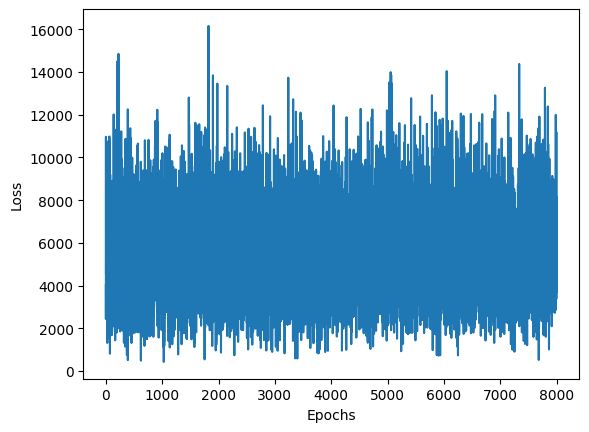

In [41]:
plt.plot(range(epochs),losses)
plt.ylabel('Loss')
plt.xlabel('Epochs')